# Host-Based Intrusion Detection System (HIDS)

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path("ADFA-LD")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)


## Obtain the Dataset & Create the Master Dataset

In [2]:
def read_syscall_file(path: Path) -> str:
    tokens = path.read_text(errors="ignore").split()
    return " ".join(tokens)


def collect_files(folder: Path, recursive: bool = False):
    pattern = "**/*.txt" if recursive else "*.txt"
    return sorted(folder.glob(pattern))


records = []

for path in collect_files(DATA_DIR / "Training_Data_Master"):
    records.append({"sequence": read_syscall_file(path), "label": 0,
                     "source": "train_normal", "file": str(path)})

for path in collect_files(DATA_DIR / "Validation_Data_Master"):
    records.append({"sequence": read_syscall_file(path), "label": 0,
                     "source": "val_normal", "file": str(path)})

for path in collect_files(DATA_DIR / "Attack_Data_Master", recursive=True):
    attack_type = path.parent.name.rsplit("_", 1)[0]
    records.append({"sequence": read_syscall_file(path), "label": 1,
                     "source": f"attack_{attack_type}", "file": str(path)})

df = pd.DataFrame.from_records(records)
df["n_calls"] = df["sequence"].str.split().apply(len)
df = df.reset_index(drop=True)

df.to_csv(ARTIFACT_DIR / "adfa_ld_master_dataset.csv", index=False)

print("Master dataset shape:", df.shape)
df.head()


Master dataset shape: (5951, 5)


,sequence,label,source,file,n_calls
0,6 6 63 6 42 120 6 195 120 6 6 114 114 1 1 252 ...,0,train_normal,ADFA-LD\Training_Data_Master\UTD-0001.txt,819
1,54 175 120 175 175 3 175 175 120 175 120 175 1...,0,train_normal,ADFA-LD\Training_Data_Master\UTD-0002.txt,137
2,6 11 45 33 192 33 5 197 192 6 33 5 3 197 192 1...,0,train_normal,ADFA-LD\Training_Data_Master\UTD-0003.txt,110
3,7 174 174 5 197 197 6 13 195 4 4 118 6 91 38 5...,0,train_normal,ADFA-LD\Training_Data_Master\UTD-0004.txt,490
4,11 45 33 192 33 5 197 192 6 33 5 3 197 192 192...,0,train_normal,ADFA-LD\Training_Data_Master\UTD-0005.txt,787


In [3]:
print(df["label"].value_counts())
print()
print(df["source"].value_counts())


label
0    5205
1     746
Name: count, dtype: int64

source
val_normal                 4372
train_normal                833
attack_Hydra_SSH            176
attack_Hydra_FTP            162
attack_Java_Meterpreter     124
attack_Web_Shell            118
attack_Adduser               91
attack_Meterpreter           75
Name: count, dtype: int64


## Exploratory Data Analysis

In [4]:
total = len(df)
normal = int((df.label == 0).sum())
attack = int((df.label == 1).sum())

print(f"Total samples:        {total}")
print(f"Normal samples:       {normal} ({normal/total:.2%})")
print(f"Attack samples:       {attack} ({attack/total:.2%})")
print()
print("Sequence length statistics (number of system calls per trace):")
print(df["n_calls"].agg(["mean", "median", "max", "min"]).round(2))


Total samples:        5951
Normal samples:       5205 (87.46%)
Attack samples:       746 (12.54%)

Sequence length statistics (number of system calls per trace):
mean       461.7
median     343.0
max       4494.0
min         75.0
Name: n_calls, dtype: float64


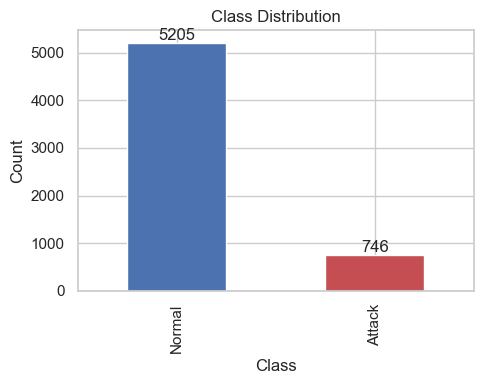

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["label"].map({0: "Normal", 1: "Attack"}).value_counts()
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()


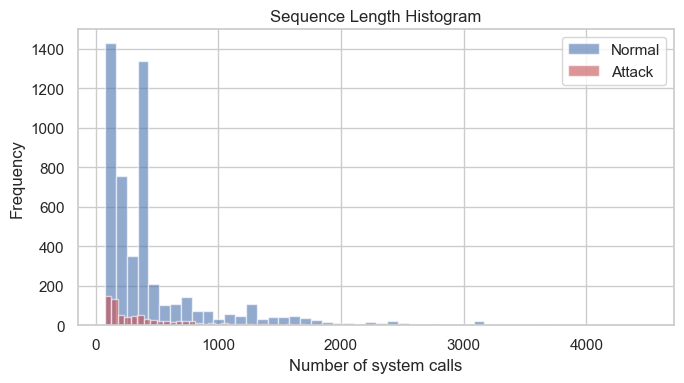

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df.loc[df.label == 0, "n_calls"], bins=50, alpha=0.6, label="Normal", color="#4C72B0")
ax.hist(df.loc[df.label == 1, "n_calls"], bins=50, alpha=0.6, label="Attack", color="#C44E52")
ax.set_title("Sequence Length Histogram")
ax.set_xlabel("Number of system calls")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()


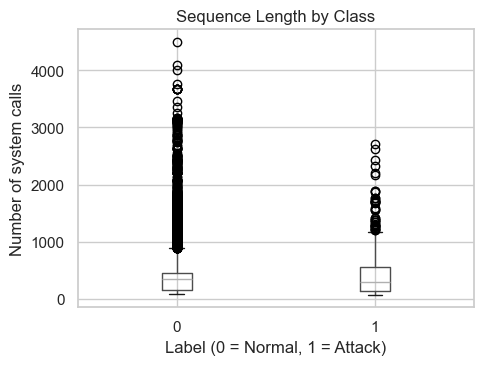

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
df.boxplot(column="n_calls", by="label", ax=ax)
ax.set_title("Sequence Length by Class")
ax.set_xlabel("Label (0 = Normal, 1 = Attack)")
ax.set_ylabel("Number of system calls")
plt.suptitle("")
plt.tight_layout()
plt.show()


**Observations:** the dataset is imbalanced toward normal traces (this motivates the SMOTE
step later), and attack traces tend to differ in length distribution from normal traces —
sequence length alone is already a weak signal, which is why later error analysis checks
whether false negatives/positives correlate with sequence length.


## Train-Test Split

Stratified 80/20 split, The test set is isolated immediately and is
never touched.


In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df["sequence"].reset_index(drop=True)
y = df["label"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain label balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest label balance:\n", y_test.value_counts(normalize=True).round(3))


Train: (4760,)  Test: (1191,)

Train label balance:
 label
0    0.875
1    0.125
Name: proportion, dtype: float64

Test label balance:
 label
0    0.875
1    0.125
Name: proportion, dtype: float64


## Stratified 5-Fold Cross-Validation

StratifiedKFold on the training data only. Every fold below is processed independently:
fold-training and fold-validation splits are created, and validation samples never
participate in any fitting operation (TF-IDF, SVD, SMOTE, or model training).


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(X_train, y_train))
print(f"Created {len(folds)} folds")
for i, (tr, val) in enumerate(folds):
    print(f"  Fold {i+1}: train={len(tr)}  val={len(val)}")


Created 5 folds
  Fold 1: train=3808  val=952
  Fold 2: train=3808  val=952
  Fold 3: train=3808  val=952
  Fold 4: train=3808  val=952
  Fold 5: train=3808  val=952


## N-Grams + TF-IDF

Each system call is treated as a "word", it is performed automatically —
and identically — by TfidfVectorizer(analyzer="word", ngram_range=(2,4), min_df=2), which
is fit only on fold-training data and then used to transform (never fit) the fold-validation
data.


## Truncated SVD Component Sweep

For each fold, TF-IDF is fit on the fold-training data, then Truncated SVD is fit at four
candidate sizes (50/100/200/300 components). A fast Logistic Regression probe scores each
configuration on the fold-validation split; the results are averaged across all 5 folds to
pick the number of components used for the rest of the notebook (recall is prioritized, since
this is an intrusion-detection task).


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score

SVD_CANDIDATES = [50, 100, 200, 300]
sweep_records = []

for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    tfidf = TfidfVectorizer(analyzer="word", ngram_range=(2, 4), min_df=2)
    Xtr_tfidf = tfidf.fit_transform(X_tr_fold)
    Xval_tfidf = tfidf.transform(X_val_fold)

    for n_comp in SVD_CANDIDATES:
        svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
        Xtr_svd = svd.fit_transform(Xtr_tfidf)
        Xval_svd = svd.transform(Xval_tfidf)

        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(Xtr_svd, y_tr_fold)
        preds = clf.predict(Xval_svd)
        proba = clf.predict_proba(Xval_svd)[:, 1]

        sweep_records.append({
            "fold": fold_idx,
            "n_components": n_comp,
            "recall": recall_score(y_val_fold, preds, zero_division=0),
            "f1": f1_score(y_val_fold, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_val_fold, proba),
        })

sweep_df = pd.DataFrame(sweep_records)
sweep_summary = sweep_df.groupby("n_components")[["recall", "f1", "roc_auc"]].mean()
sweep_summary


,recall,f1,roc_auc
n_components,,,
50,0.462241,0.559041,0.936708
100,0.557689,0.649553,0.954960
200,0.606261,0.696256,0.961721
300,0.618011,0.708021,0.963109


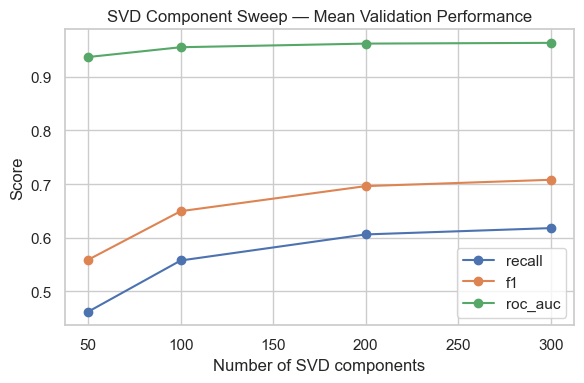

Selected SVD component count: 300


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sweep_summary.plot(marker="o", ax=ax)
ax.set_title("SVD Component Sweep — Mean Validation Performance")
ax.set_xlabel("Number of SVD components")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

BEST_SVD_N = int(sweep_summary.sort_values(["recall", "f1", "roc_auc"], ascending=False).index[0])
print("Selected SVD component count:", BEST_SVD_N)


## Per-Fold Pipeline — SMOTE + Train Models

For every fold: `TF-IDF (fit on fold-train) -> SVD (fit on fold-train, n=BEST_SVD_N) -> SMOTE
(fold-train only)`, then train Random Forest, SVM, XGBoost, LightGBM, CatBoost, a soft-Voting
ensemble (RF+XGB+LGBM+CatBoost), and a Stacking ensemble (RF+SVM+XGB+LGBM+CatBoost with a
Logistic Regression meta-model). Every model is evaluated on the untouched, non-resampled
fold-validation features.


In [16]:
from imblearn.over_sampling import SMOTE

fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"=== Fold {fold_idx + 1}/5 ===")
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    tfidf = TfidfVectorizer(analyzer="word", ngram_range=(2, 4), min_df=2) #ngram
    Xtr_tfidf = tfidf.fit_transform(X_tr_fold)
    Xval_tfidf = tfidf.transform(X_val_fold)

    svd = TruncatedSVD(n_components=BEST_SVD_N, random_state=RANDOM_STATE)
    Xtr_svd = svd.fit_transform(Xtr_tfidf)
    Xval_svd = svd.transform(Xval_tfidf)

    before_counts = y_tr_fold.value_counts().to_dict()
    smote = SMOTE(random_state=RANDOM_STATE)
    Xtr_res, ytr_res = smote.fit_resample(Xtr_svd, y_tr_fold)
    after_counts = pd.Series(ytr_res).value_counts().to_dict()
    print(f"  Class balance before SMOTE: {before_counts}  after: {after_counts}")

    for name in MODEL_NAMES:
        model = make_model(name)
        model.fit(Xtr_res, ytr_res)
        preds = model.predict(Xval_svd)
        scores = get_scores(model, Xval_svd)
        metrics = evaluate(y_val_fold, preds, scores)
        metrics.update({"fold": fold_idx, "model": name})
        fold_results.append(metrics)
        print(f"    {name:12s} recall={metrics['recall']:.3f}  f1={metrics['f1']:.3f}  "
              f"roc_auc={metrics['roc_auc']:.3f}")

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(ARTIFACT_DIR / "fold_results.csv", index=False)
fold_results_df.head()


=== Fold 1/5 ===
  Class balance before SMOTE: {0: 3330, 1: 478}  after: {0: 3330, 1: 3330}
    RandomForest recall=0.857  f1=0.840  roc_auc=0.967
    SVM          recall=0.941  f1=0.830  roc_auc=0.971
    XGBoost      recall=0.824  f1=0.813  roc_auc=0.971
    LightGBM     recall=0.815  f1=0.805  roc_auc=0.973
    CatBoost     recall=0.866  f1=0.814  roc_auc=0.980
    Voting       recall=0.832  f1=0.815  roc_auc=0.973
    Stacking     recall=0.782  f1=0.805  roc_auc=0.964
=== Fold 2/5 ===
  Class balance before SMOTE: {0: 3330, 1: 478}  after: {0: 3330, 1: 3330}
    RandomForest recall=0.849  f1=0.821  roc_auc=0.969
    SVM          recall=0.924  f1=0.789  roc_auc=0.964
    XGBoost      recall=0.798  f1=0.779  roc_auc=0.975
    LightGBM     recall=0.849  f1=0.808  roc_auc=0.976
    CatBoost     recall=0.866  f1=0.798  roc_auc=0.973
    Voting       recall=0.849  f1=0.805  roc_auc=0.971
    Stacking     recall=0.798  f1=0.782  roc_auc=0.968
=== Fold 3/5 ===
  Class balance before SMOTE:

,accuracy,precision,recall,f1,roc_auc,mcc,balanced_accuracy,fold,model
0,0.959034,0.822581,0.857143,0.839506,0.967093,0.816265,0.915366,0,RandomForest
1,0.951681,0.741722,0.941176,0.829630,0.970543,0.809660,0.947179,0,SVM
2,0.952731,0.803279,0.823529,0.813278,0.970729,0.786303,0.897359,0,XGBoost
3,0.950630,0.795082,0.815126,0.804979,0.973257,0.776801,0.892557,0,LightGBM
4,0.950630,0.768657,0.865546,0.814229,0.979713,0.787718,0.914166,0,CatBoost


    RandomForest recall=0.857  f1=0.840  roc_auc=0.967


    SVM          recall=0.941  f1=0.830  roc_auc=0.971


    XGBoost      recall=0.824  f1=0.813  roc_auc=0.971


...

    LightGBM     recall=0.858  f1=0.844  roc_auc=0.980


    CatBoost     recall=0.842  f1=0.828  roc_auc=0.982


    Voting       recall=0.858  f1=0.841  roc_auc=0.978


    Stacking     recall=0.833  f1=0.837  roc_auc=0.975


,accuracy,precision,recall,f1,roc_auc,mcc,balanced_accuracy,fold,model
0,0.959034,0.822581,0.857143,0.839506,0.966694,0.816265,0.915366,0,RandomForest
1,0.951681,0.741722,0.941176,0.829630,0.970553,0.809660,0.947179,0,SVM
2,0.952731,0.803279,0.823529,0.813278,0.970729,0.786303,0.897359,0,XGBoost
3,0.950630,0.795082,0.815126,0.804979,0.973257,0.776801,0.892557,0,LightGBM
4,0.950630,0.768657,0.865546,0.814229,0.979713,0.787718,0.914166,0,CatBoost


In [17]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "mcc", "balanced_accuracy"]
mean_std_summary = fold_results_df.groupby("model")[metric_cols].agg(["mean", "std"])
mean_std_summary


accuracy           precision              recall            \
                  mean       std      mean       std      mean       std   
model                                                                      
CatBoost      0.953361  0.005387  0.783022  0.031451  0.871064  0.023837   
LightGBM      0.955042  0.004662  0.803784  0.022515  0.849202  0.020080   
RandomForest  0.958824  0.002915  0.817951  0.015098  0.864342  0.019873   
SVM           0.938025  0.009247  0.689305  0.034286  0.924636  0.013136   
Stacking      0.955252  0.006872  0.819360  0.030538  0.825728  0.034692   
Voting        0.955042  0.004356  0.799984  0.021646  0.855910  0.016504   
XGBoost       0.953361  0.006241  0.799105  0.025289  0.839132  0.027253   

                    f1             roc_auc                 mcc            \
                  mean       std      mean       std      mean       std   
model                                                                      
CatBoost      0.824226  0.018116  0.980415  0.004382  0.799262  0.020597   
LightGBM      0.825730  0.017942  0.978302  0.003655  0.800437  0.020433   
RandomForest  0.840352  0.011728  0.970129  0.005050  0.817251  0.013552   
SVM           0.789612  0.027006  0.969848  0.004820  0.765521  0.029955   
Stacking      0.822230  0.027745  0.972283  0.006147  0.796843  0.031529   
Voting        0.826884  0.016210  0.976760  0.004496  0.801770  0.018468   
XGBoost       0.818561  0.024847  0.977446  0.004880  0.792178  0.028436   

             balanced_accuracy            
                          mean       std  
model                                     
CatBoost              0.918118  0.011212  
LightGBM              0.909708  0.010626  
RandomForest          0.918359  0.009624  
SVM                   0.932290  0.010815  
Stacking              0.899773  0.018144  
Voting                0.912582  0.008911  
XGBoost               0.904433  0.015043

## Compare Models & Select the Best

Ranking priority: **Recall > F1 > ROC-AUC**, since in intrusion detection missing an attack
(false negative) is more costly than a false alarm.


In [18]:
mean_summary = fold_results_df.groupby("model")[metric_cols].mean()
comparison_table = mean_summary.sort_values(["recall", "f1", "roc_auc"], ascending=False).round(4)
best_model_name = comparison_table.index[0]

print("Model comparison (mean across 5 folds), ranked by Recall > F1 > ROC-AUC:\n")
print(comparison_table)
print(f"\nBest-performing model: {best_model_name}")


Model comparison (mean across 5 folds), ranked by Recall > F1 > ROC-AUC:

              accuracy  precision  recall      f1  roc_auc     mcc  \
model                                                                
SVM             0.9380     0.6893  0.9246  0.7896   0.9698  0.7655   
CatBoost        0.9534     0.7830  0.8711  0.8242   0.9804  0.7993   
RandomForest    0.9588     0.8180  0.8643  0.8404   0.9701  0.8173   
Voting          0.9550     0.8000  0.8559  0.8269   0.9768  0.8018   
LightGBM        0.9550     0.8038  0.8492  0.8257   0.9783  0.8004   
XGBoost         0.9534     0.7991  0.8391  0.8186   0.9774  0.7922   
Stacking        0.9553     0.8194  0.8257  0.8222   0.9723  0.7968   

              balanced_accuracy  
model                            
SVM                      0.9323  
CatBoost                 0.9181  
RandomForest             0.9184  
Voting                   0.9126  
LightGBM                 0.9097  
XGBoost                  0.9044  
Stacking               

## Retrain the Best Model on the Full Training Set

`Training Data -> TF-IDF (fit) -> SVD (fit) -> SMOTE -> Best Model`. The fitted TF-IDF, SVD,
and model objects are saved to `artifacts/`.


In [17]:
import joblib

tfidf_final = TfidfVectorizer(analyzer="word", ngram_range=(2, 4), min_df=2)
Xtr_tfidf_final = tfidf_final.fit_transform(X_train)
Xtest_tfidf_final = tfidf_final.transform(X_test)

svd_final = TruncatedSVD(n_components=BEST_SVD_N, random_state=RANDOM_STATE)
Xtr_svd_final = svd_final.fit_transform(Xtr_tfidf_final)
Xtest_svd_final = svd_final.transform(Xtest_tfidf_final)

smote_final = SMOTE(random_state=RANDOM_STATE)
Xtr_res_final, ytr_res_final = smote_final.fit_resample(Xtr_svd_final, y_train)

best_model_final = make_model(best_model_name)
best_model_final.fit(Xtr_res_final, ytr_res_final)

joblib.dump(tfidf_final, ARTIFACT_DIR / "tfidf.pkl")
joblib.dump(svd_final, ARTIFACT_DIR / "svd.pkl")
joblib.dump(best_model_final, ARTIFACT_DIR / "best_model.pkl")

print(f"Final model trained on {Xtr_res_final.shape[0]} samples "
      f"(after SMOTE) x {Xtr_res_final.shape[1]} SVD features: {best_model_name}")


Final model trained on 8326 samples (after SMOTE) x 300 SVD features: SVM


## Evaluate on Unseen Test Data

`Test Data -> TF-IDF (transform only) -> SVD (transform only) -> Prediction`. No fitting of
any kind happens on the test set. These are the true, unbiased performance numbers for the
system.


In [18]:
test_preds = best_model_final.predict(Xtest_svd_final)
test_scores = get_scores(best_model_final, Xtest_svd_final)
test_metrics = evaluate(y_test, test_preds, test_scores)

print(f"Held-out test performance ({best_model_name}):")
for k, v in test_metrics.items():
    print(f"  {k:18s}: {v:.4f}")


Held-out test performance (SVM):
  accuracy          : 0.9538
  precision         : 0.7448
  recall            : 0.9597
  f1                : 0.8387
  roc_auc           : 0.9812
  mcc               : 0.8212
  balanced_accuracy : 0.9564


In [19]:
print(classification_report(y_test, test_preds, target_names=["Normal", "Attack"]))

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97      1042
      Attack       0.74      0.96      0.84       149

    accuracy                           0.95      1191
   macro avg       0.87      0.96      0.91      1191
weighted avg       0.96      0.95      0.96      1191



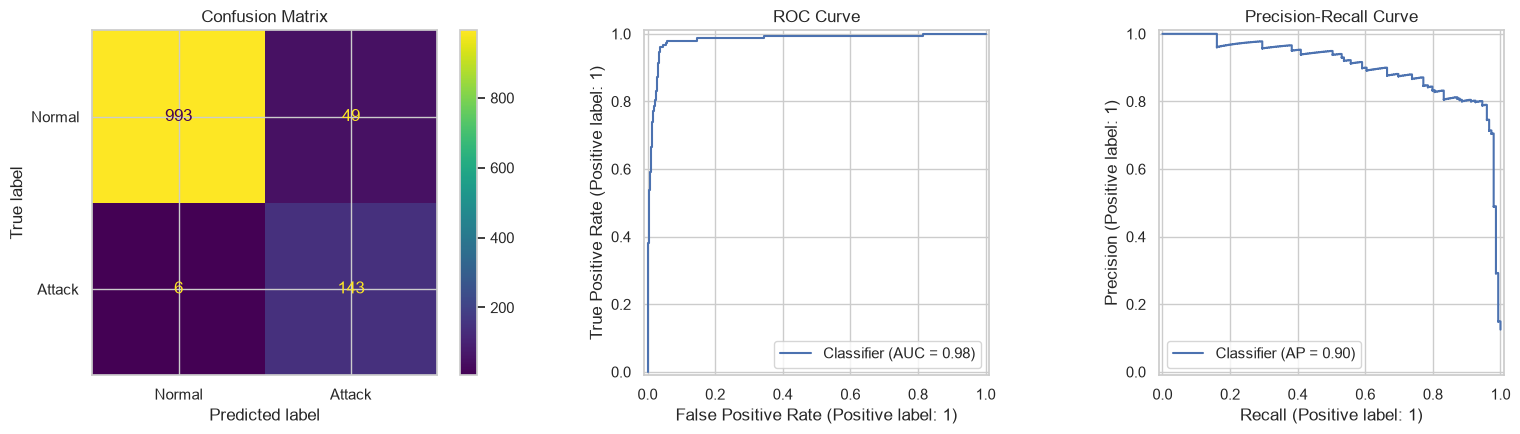

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=["Normal", "Attack"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


## Feature Importance Analysis

Random Forest, XGBoost, LightGBM, and CatBoost are each (re)trained on the full-training
SVD+SMOTE features and expose `feature_importances_` — but those importances are in
**SVD-component space**, not directly interpretable as N-grams. Since Truncated SVD is a
linear projection (`X_svd = X_tfidf @ V.T`), component-level importances are back-projected
onto the original TF-IDF N-gram vocabulary via `|V.T @ importances|` to recover the top-20
most influential N-gram features per model.


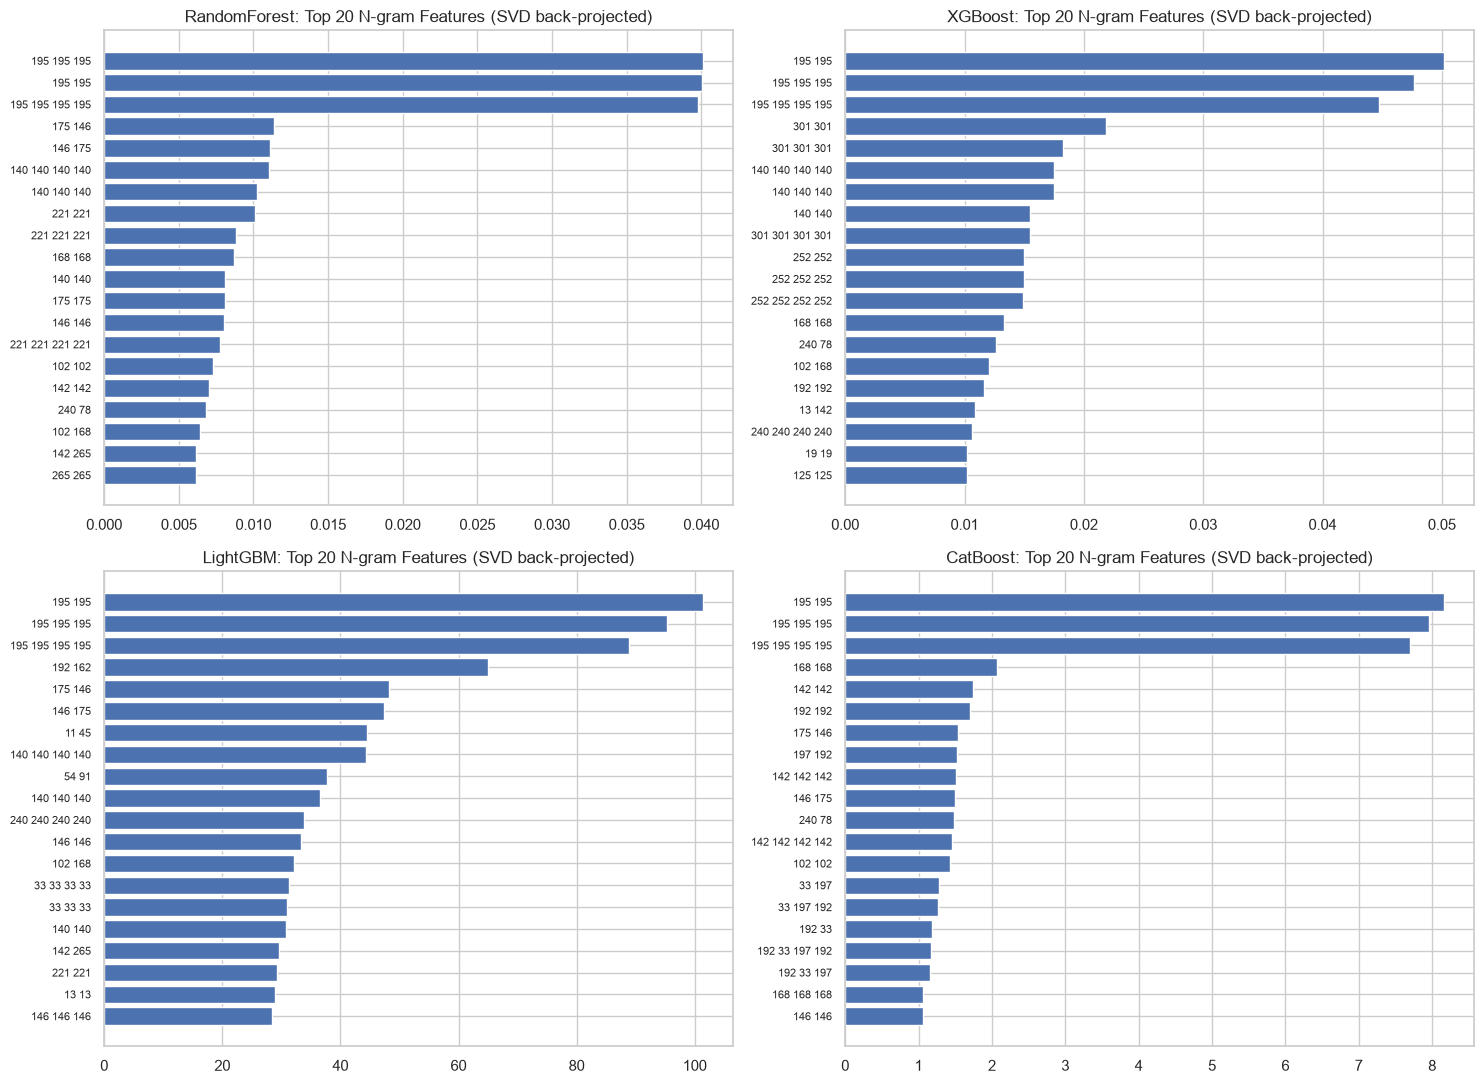

In [21]:
feature_names = np.array(tfidf_final.get_feature_names_out())
components = svd_final.components_  # shape: (n_components, n_tfidf_features)

tree_model_names = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ngram_importance_store = {}
for ax, name in zip(axes.ravel(), tree_model_names):
    m = make_model(name)
    m.fit(Xtr_res_final, ytr_res_final)
    comp_importance = m.feature_importances_
    ngram_importance = np.abs(components.T @ comp_importance)
    top_idx = np.argsort(ngram_importance)[::-1][:20]
    top_features = feature_names[top_idx]
    top_values = ngram_importance[top_idx]
    ngram_importance_store[name] = list(zip(top_features, top_values))

    ax.barh(top_features[::-1], top_values[::-1], color="#4C72B0")
    ax.set_title(f"{name}: Top 20 N-gram Features (SVD back-projected)")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


## SHAP Analysis

SHAP's `TreeExplainer` is applied to an XGBoost model (trained on the same full-training
SVD+SMOTE features) since it supports fast, exact explanations for tree ensembles —
`TreeExplainer` does not directly support the Voting/Stacking meta-ensembles. Component-space
SHAP values are shown natively (Summary Plot, Waterfall Plot), and are additionally
back-projected onto the N-gram vocabulary (same linear technique as Step 23) to produce the
Feature Impact Plot in genuinely interpretable terms.


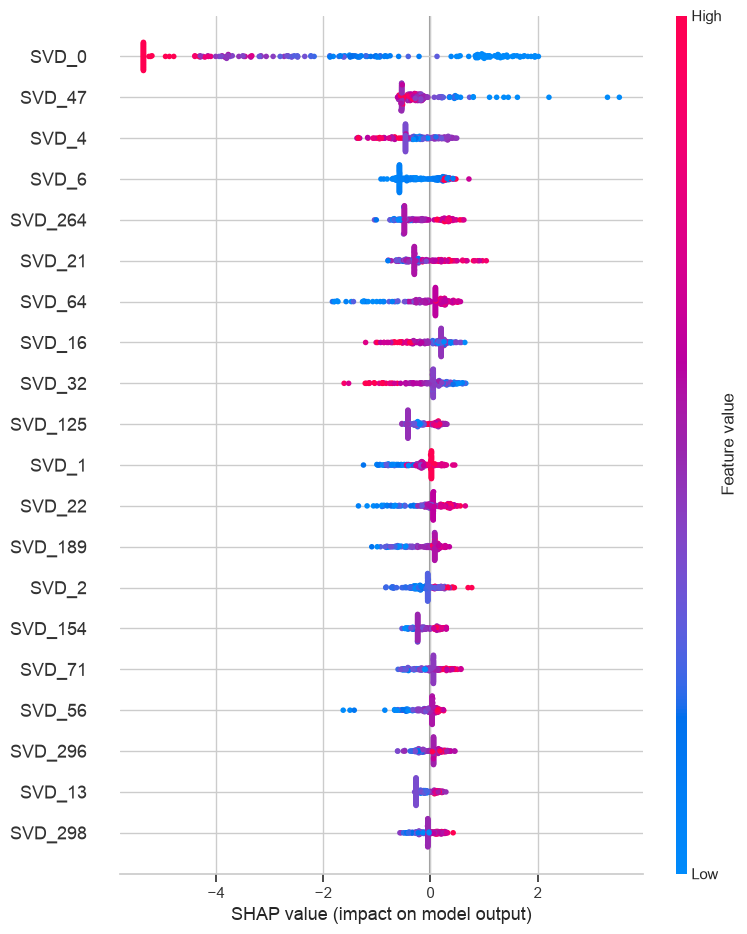

In [22]:
import shap

xgb_for_shap = make_model("XGBoost")
xgb_for_shap.fit(Xtr_res_final, ytr_res_final)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(Xtest_svd_final.shape[0], size=min(200, Xtest_svd_final.shape[0]), replace=False)
X_shap_sample = Xtest_svd_final[sample_idx]
svd_feature_names = [f"SVD_{i}" for i in range(X_shap_sample.shape[1])]

explainer = shap.TreeExplainer(xgb_for_shap)
shap_exp = explainer(X_shap_sample)
if shap_exp.values.ndim == 3:
    shap_exp = shap_exp[..., 1]

shap.summary_plot(shap_exp.values, X_shap_sample, feature_names=svd_feature_names, show=True)


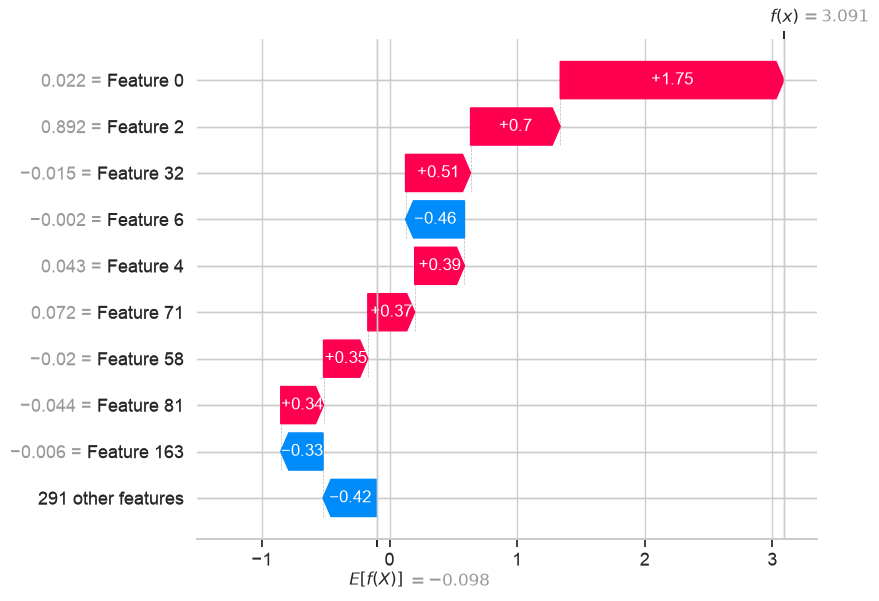

In [23]:
y_test_sample = y_test.values[sample_idx]
attack_local_idx = np.where(y_test_sample == 1)[0]
pick = int(attack_local_idx[0]) if len(attack_local_idx) else 0

shap.plots.waterfall(shap_exp[pick])


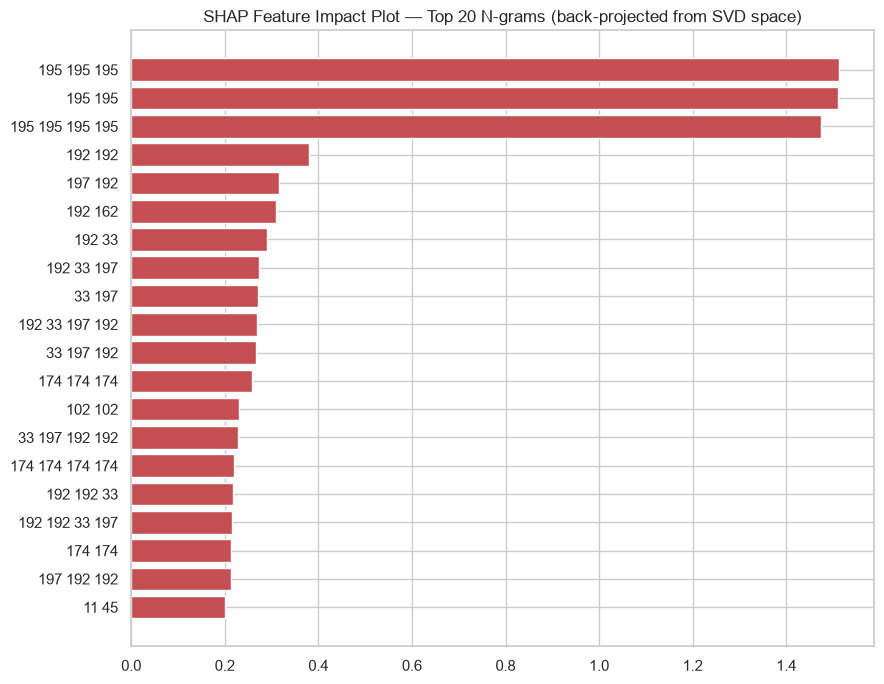

In [24]:
mean_abs_shap_comp = np.abs(shap_exp.values).mean(axis=0)
ngram_shap_importance = np.abs(components.T @ mean_abs_shap_comp)
shap_top_idx = np.argsort(ngram_shap_importance)[::-1][:20]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feature_names[shap_top_idx][::-1], ngram_shap_importance[shap_top_idx][::-1], color="#C44E52")
ax.set_title("SHAP Feature Impact Plot — Top 20 N-grams (back-projected from SVD space)")
plt.tight_layout()
plt.show()


### Interpretation notes

- **Impact of SVD:** reducing the sparse, high-dimensional TF-IDF N-gram space to
  `BEST_SVD_N` dense components was necessary to make SMOTE and SVM/CatBoost training
  tractable; the sweep above shows how validation recall/F1/ROC-AUC changed across component
  counts, and the chosen size trades off information loss against overfitting risk on a
  relatively small attack class.
- **Impact of SMOTE:** the "before/after" class counts above show SMOTE fully balancing the
  fold-training (and final full-training) data; because it is applied strictly after the
  train/validation and train/test splits, none of the reported validation or test metrics are
  inflated by synthetic samples leaking into evaluation data.
- **Impact of Voting vs. Stacking vs. best individual model:** compare the three CV blocks
  above — whichever ensemble (or single model) tops the Recall > F1 > ROC-AUC ranking was
  carried forward to the final retrain and is the one reported on the held-out test set.
- **Most important attack patterns:** the N-gram lists above (from both raw tree-model
  importance and SHAP) indicate which short system-call subsequences are most predictive;
  cross-referencing these against the false-negative examples in Step 25 shows whether missed
  attacks systematically avoid these "tell-tale" patterns (i.e., mimic normal call sequences).
- **Performance on unseen data:** the Step 22 test metrics are the only numbers in this
  notebook computed on data that never influenced any fitting decision, and are therefore the
  most honest estimate of real-world detection performance.
